In [2]:
import os
import shutil
import random
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [3]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [4]:
!unzip -q /content/dataset.zip -d /content/dataset

Импортируем необходимые библиотеке, открываем файлы с датасетом

Собираем файл test_annotation, делим датасеты на необходимые директории

In [5]:

base_dir = "/content/dataset/dataset"
train_dir = os.path.join(base_dir, "train")
proliv_dir = os.path.join(base_dir, "proliv")
test_dir = os.path.join(base_dir, "test", "imgs")
annotation_path = os.path.join(base_dir, "test", "test_annotation.txt")

os.makedirs(test_dir, exist_ok=True)


train_imgs = os.listdir(train_dir)
proliv_imgs = os.listdir(proliv_dir)

with open(annotation_path, "w") as f:
    for fname in train_imgs:
        src = os.path.join(train_dir, fname)
        dst = os.path.join(test_dir, fname)
        shutil.copy(src, dst)
        f.write(f"{fname} no_proliv\n")

    for fname in proliv_imgs:
        src = os.path.join(proliv_dir, fname)
        dst = os.path.join(test_dir, fname)
        shutil.copy(src, dst)
        f.write(f"{fname} proliv\n")

print("Тестовая выборка и test_annotation.txt успешно созданы!")
print("Файл:", annotation_path)


Тестовая выборка и test_annotation.txt успешно созданы!
Файл: /content/dataset/dataset/test/test_annotation.txt


Предобрабатываем изображенения, собираем датасеты

In [6]:
class ImageFolderSimple(Dataset):
    def __init__(self, folder_path, transform=None):
        self.files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(('.jpg','.png'))]
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0

In [7]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

base_dir = "/content/dataset/dataset"
train_path = os.path.join(base_dir, "train")
proliv_path = os.path.join(base_dir, "proliv")
test_imgs_path = os.path.join(base_dir, "test", "imgs")
test_ann_path = os.path.join(base_dir, "test", "test_annotation.txt")

train_data = ImageFolderSimple(train_path, transform=transform)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

In [8]:

val_split = 0.2
val_size = int(len(train_data) * val_split)
train_size = len(train_data) - val_size
train_subset, val_subset = torch.utils.data.random_split(train_data, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)


Собираем и обучаем автоэнкодер

In [9]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.ReLU(True)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out


Epoch [1/10] | Train Loss: 0.00161 | Val Loss: 0.00033
Epoch [2/10] | Train Loss: 0.00024 | Val Loss: 0.00019
Epoch [3/10] | Train Loss: 0.00019 | Val Loss: 0.00010
Epoch [4/10] | Train Loss: 0.00008 | Val Loss: 0.00006
Epoch [5/10] | Train Loss: 0.00007 | Val Loss: 0.00009
Epoch [6/10] | Train Loss: 0.00006 | Val Loss: 0.00004
Epoch [7/10] | Train Loss: 0.00005 | Val Loss: 0.00004
Epoch [8/10] | Train Loss: 0.00004 | Val Loss: 0.00007
Epoch [9/10] | Train Loss: 0.00004 | Val Loss: 0.00007
Epoch [10/10] | Train Loss: 0.00003 | Val Loss: 0.00003


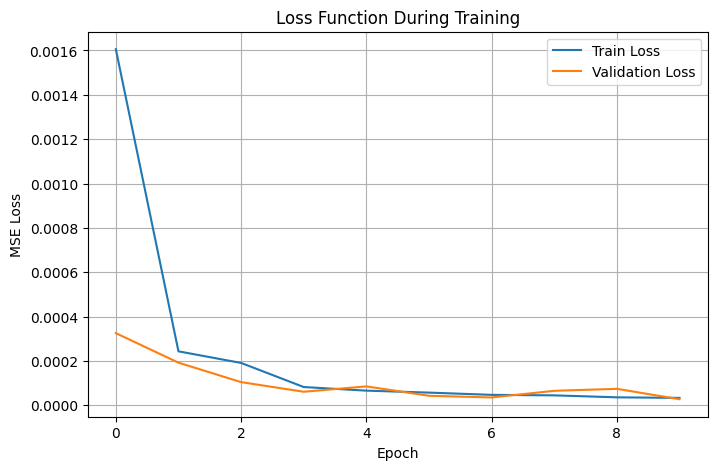

In [10]:
model = ConvAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 10
train_losses, val_losses = [], []

for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for img, _ in train_loader:
        img = img.to(device)
        output = model(img)
        loss = criterion(output, img)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Валидация
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for img, _ in val_loader:
            img = img.to(device)
            output = model(img)
            loss = criterion(output, img)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{n_epochs}] | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")

# === ГРАФИКИ ЛОССОВ ===
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss Function During Training')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

torch.save(model.state_dict(), "autoencoder.pth")

Имплементируем две функции одна для подбора оптимального MSE, вторая для предсказания классов

In [11]:
def calc_mse_list(model, folder):
    scores = []
    for fname in os.listdir(folder):
        img_path = os.path.join(folder, fname)
        img = Image.open(img_path).convert('RGB')
        img_t = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            recon = model(img_t)
        score = ((img_t.cpu().numpy() - recon.cpu().numpy()) ** 2).mean()
        scores.append(score)
    return np.array(scores)

# MSE для нормальных и проливов
mse_normal = calc_mse_list(model, os.path.join(base_dir, "train"))
mse_proliv = calc_mse_list(model, os.path.join(base_dir, "proliv"))


# Подбор порога (можно взять середину между медианами)
threshold = ((np.median(mse_normal) + np.median(mse_proliv)) / 2)* 0.6
print("Оптимальный threshold:", threshold)


Оптимальный threshold: 0.00017247064


In [12]:
def classify_image(model, img_path, threshold):
    img = Image.open(img_path).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        recon = model(img_t)
    score = mse(img_t.cpu().numpy(), recon.cpu().numpy())
    return ("proliv" if score > threshold else "no_proliv"), score

In [16]:
def classify_image(model, img_path, threshold):
    img = Image.open(img_path).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        recon = model(img_t)
    score = ((img_t.cpu().numpy() - recon.cpu().numpy()) ** 2).mean()
    return ("proliv" if score > threshold else "no_proliv"), score

Собираем данные и предсказания, рассчитываем метрики

Оптимальный threshold: 0.00017247064


100%|██████████| 10154/10154 [00:18<00:00, 542.04it/s]


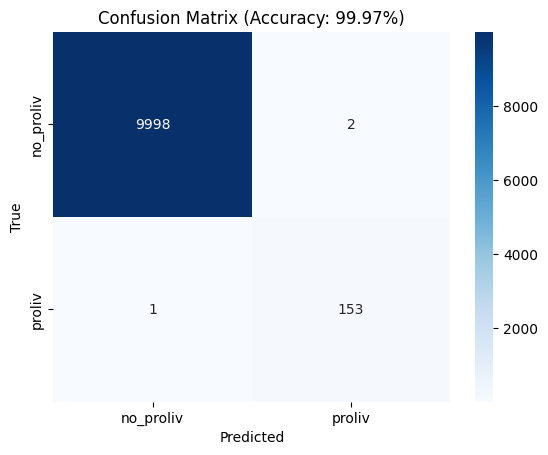

True Positive Rate (TPR): 99.35%
True Negative Rate (TNR): 99.98%


In [17]:
mse_normal = calc_mse_list(model, os.path.join(base_dir, "train"))
mse_proliv = calc_mse_list(model, os.path.join(base_dir, "proliv"))
threshold = ((np.median(mse_normal) + np.median(mse_proliv)) / 2)*0.6
print("Оптимальный threshold:", threshold)

with open(test_ann_path) as f:
    lines = [line.strip().split() for line in f.readlines()]

y_true, y_pred = [], []

for fname, label in tqdm(lines):
    img_path = os.path.join(test_imgs_path, fname)
    pred, score = classify_image(model, img_path, threshold)
    y_true.append(label)
    y_pred.append(pred)

cm = confusion_matrix(y_true, y_pred, labels=["no_proliv", "proliv"])
acc = accuracy_score(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["no_proliv","proliv"], yticklabels=["no_proliv","proliv"])
plt.title(f'Confusion Matrix (Accuracy: {acc*100:.2f}%)')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

tp = cm[1,1]
tn = cm[0,0]
fp = cm[0,1]
fn = cm[1,0]
TPR = tp / (tp + fn + 1e-8)
TNR = tn / (tn + fp + 1e-8)

print(f"True Positive Rate (TPR): {TPR*100:.2f}%")
print(f"True Negative Rate (TNR): {TNR*100:.2f}%")